# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari kaggel tentang heart disease (Cleveland) dari UCI Machine Learning Repository. Dataset ini digunakan untuk memprediksi apakah seorang pasien memiliki penyakit jantung atau tidak berdasarkan 13 atribut medis.
   **Informasi Atribut Utama:**
    1. `age`: Usia pasien (tahun)
    2. `sex`: Jenis kelamin (1 = pria, 0 = wanita)
    3. `cp`: Tipe nyeri dada (4 tipe)
    4. `trestbps`: Tekanan darah saat istirahat (mm Hg)
    5. `chol`: Kolesterol serum (mg/dl)
    6. `target`: Diagnosis penyakit jantung (0 = tidak ada, >0 = ada penyakit)


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import os
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
raw_folder = '../heart_disease_raw' if os.path.exists('../preprocessing') else 'heart_disease_raw'
os.makedirs(raw_folder, exist_ok=True)
raw_path = os.path.join(raw_folder, 'heart_disease.csv')

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
if not os.path.exists(raw_path):
    urllib.request.urlretrieve(url, raw_path)
    print("Dataset berhasil diunduh dan disimpan di folder raw!")
else:
    print("Dataset sudah ada di folder raw.")

columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

df = pd.read_csv(raw_path, names=columns)
df.head()

Dataset sudah ada di folder raw.


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB

Distribusi Target (0: Sehat, 1-4: Sakit):
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


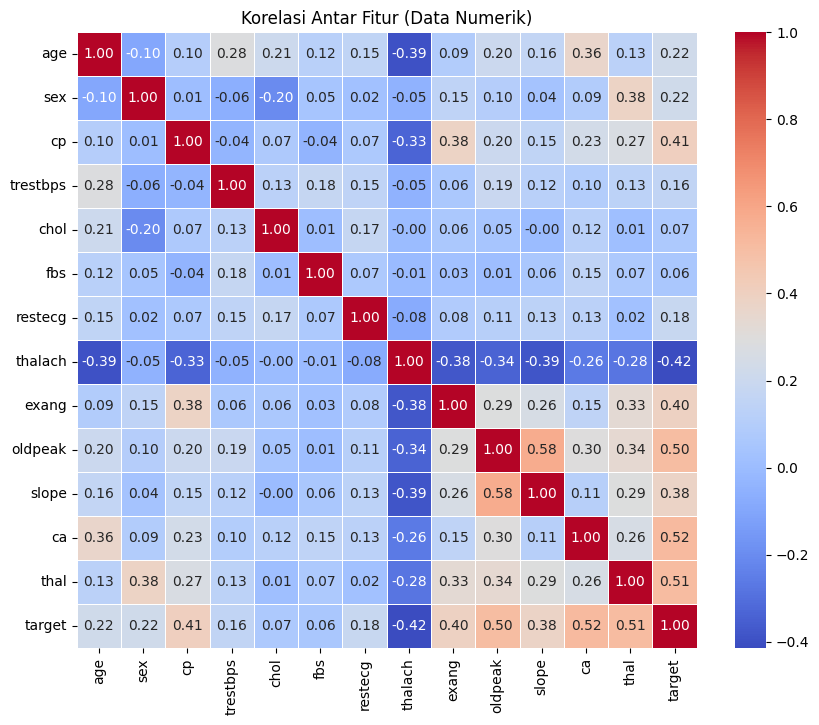

In [3]:
print("Informasi Dataset:")
df.info()

print("\nDistribusi Target (0: Sehat, 1-4: Sakit):")
print(df['target'].value_counts())

plt.figure(figsize=(10, 8))
df_temp = df.replace('?', np.nan).apply(pd.to_numeric)
sns.heatmap(df_temp.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Korelasi Antar Fitur (Data Numerik)')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
df.replace('?', np.nan, inplace=True)

df['ca'] = pd.to_numeric(df['ca'], errors='coerce')
df['thal'] = pd.to_numeric(df['thal'], errors='coerce')

df['ca'] = df['ca'].fillna(df['ca'].median())
df['thal'] = df['thal'].fillna(df['thal'].median())

df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

scaler = StandardScaler()
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
df[num_cols] = scaler.fit_transform(df[num_cols])

clean_folder = '../preprocessing/heart_disease_preprocessing' if os.path.exists('../preprocessing') else 'heart_disease_preprocessing'
os.makedirs(clean_folder, exist_ok=True)
clean_path = os.path.join(clean_folder, 'dataset_clean.csv')

df.to_csv(clean_path, index=False)
print(f"Data preprocessing selesai. Data bersih disimpan di: {clean_path}")
display(df.head())

Data preprocessing selesai. Data bersih disimpan di: heart_disease_preprocessing/dataset_clean.csv


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0.948726,1.0,1.0,0.757525,-0.264900,1.0,2.0,0.017197,0.0,1.087338,3.0,0.0,6.0,0
1,1.392002,1.0,4.0,1.611220,0.760415,0.0,2.0,-1.821905,1.0,0.397182,2.0,3.0,3.0,1
2,1.392002,1.0,4.0,-0.665300,-0.342283,0.0,2.0,-0.902354,1.0,1.346147,2.0,2.0,7.0,1
3,-1.932564,1.0,3.0,-0.096170,0.063974,0.0,0.0,1.637359,0.0,2.122573,3.0,0.0,3.0,0
4,-1.489288,0.0,2.0,-0.096170,-0.825922,0.0,2.0,0.980537,0.0,0.310912,1.0,0.0,3.0,0


In [5]:
!zip -r /content/my_folder.zip /content/heart_disease_raw

  adding: content/heart_disease_raw/ (stored 0%)
  adding: content/heart_disease_raw/heart_disease.csv (deflated 80%)


In [6]:
!zip -r /content/heart_disease_preprocessing.zip /content/heart_disease_preprocessing

  adding: content/heart_disease_preprocessing/ (stored 0%)
  adding: content/heart_disease_preprocessing/dataset_clean.csv (deflated 80%)
